In [ ]:
# --- project bootstrap (added during repo consolidation) ---
# Resolves the project root so the notebook runs from notebooks/ or from the repo root,
# and puts src/ on sys.path so `import laptop_price` works.
import os, sys, pathlib

_here = pathlib.Path.cwd()
for _cand in (_here, *_here.parents):
    if (_cand / "pyproject.toml").exists():
        PROJECT_ROOT = _cand
        break
else:
    raise RuntimeError("pyproject.toml not found - run this notebook inside the repo")

os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))
print(f"project root: {PROJECT_ROOT}")


# Clustering Models

## Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, learning_curve
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("data/processed/model_ready_data.csv", index_col=0)

# Handle outliers using IQR method on target
Q1 = df['price_preview'].quantile(0.01)
Q3 = df['price_preview'].quantile(0.99)
df_clean = df[(df['price_preview'] >= Q1) & (df['price_preview'] <= Q3)]



X = df_clean.drop('price_preview', axis=1)
y = np.log1p(df_clean['price_preview'])  # Log transform for large values

# Split: 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Use RobustScaler for better handling of outliers
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Original samples: {len(df)}, After outlier removal: {len(df_clean)}")
print(f"Train: {X_train.shape[0]}, Validation: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Original samples: 15517, After outlier removal: 15209
Train: 10646, Validation: 2281, Test: 2282


## Clustering Models

In [3]:
df.isna().sum()

price_preview            0
RAM_SIZE                 0
SSD_SIZE                 0
HDD_SIZE                 0
match_score              0
cores                    0
cpu_mark                 0
tdp                      0
gpu_g3d_mark             0
gpu_g2d_mark             0
gpu_tdp                  0
SCREEN_SIZE_SNAPPED      0
SCREEN_RESOLUTION_ENC    0
model_family             0
RAM_TYPE                 0
spec_Etat                0
dtype: int64

In [4]:
# Use all scaled data for clustering (include price_preview)
X_clust_source = X.copy()
X_clust_source["price_preview"] = df_clean.loc[X.index, "price_preview"]
# fit once, on the clustering source (was: a second fit_transform that
# silently discarded the train-fitted scaler)
cluster_scaler = RobustScaler()
X_all_scaled = cluster_scaler.fit_transform(X_clust_source)

# Find optimal number of clusters using Elbow method and Silhouette scores
silhouette_scores = []
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans_temp.fit(X_all_scaled)
    silhouette_scores.append(silhouette_score(X_all_scaled, kmeans_temp.labels_))
    inertias.append(kmeans_temp.inertia_)

# Find best k based on silhouette score
best_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters (by silhouette): {best_k}")
print(f"Silhouette scores per k: {dict(zip(k_range, [f'{s:.4f}' for s in silhouette_scores]))}")

# 1. K-Means++ with optimal k
kmeans = KMeans(n_clusters=best_k, init='k-means++', n_init=20, max_iter=500, random_state=42)
kmeans_labels = kmeans.fit_predict(X_all_scaled)
kmeans_sil = silhouette_score(X_all_scaled, kmeans_labels)
print(f"\nK-Means++ (k={best_k}) Silhouette: {kmeans_sil:.4f}")

# 2. DBSCAN with parameter search
best_dbscan_sil = -1
best_eps, best_min_samples = 2.5, 5
for eps in [1.5, 2.0, 2.5, 3.0, 3.5]:
    for min_samples in [3, 5, 7, 10]:
        dbscan_temp = DBSCAN(eps=eps, min_samples=min_samples)
        labels_temp = dbscan_temp.fit_predict(X_all_scaled)
        n_clusters_temp = len(set(labels_temp)) - (1 if -1 in labels_temp else 0)
        if n_clusters_temp > 1:
            mask_temp = labels_temp != -1
            if sum(mask_temp) > 10:
                sil_temp = silhouette_score(X_all_scaled[mask_temp], labels_temp[mask_temp])
                if sil_temp > best_dbscan_sil:
                    best_dbscan_sil = sil_temp
                    best_eps, best_min_samples = eps, min_samples

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels = dbscan.fit_predict(X_all_scaled)
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
if n_clusters_dbscan > 1:
    mask = dbscan_labels != -1
    dbscan_sil = silhouette_score(X_all_scaled[mask], dbscan_labels[mask])
    print(f"DBSCAN (eps={best_eps}, min_samples={best_min_samples}) Silhouette: {dbscan_sil:.4f}")
    print(f"  Clusters: {n_clusters_dbscan}, Noise points: {sum(dbscan_labels==-1)}")
else:
    dbscan_sil = 0
    print(f"DBSCAN found {n_clusters_dbscan} cluster(s) - no valid clustering")

# 3. Agglomerative Hierarchical with different linkages
best_agg_sil = -1
best_linkage = 'ward'
for linkage in ['ward', 'complete', 'average']:
    agg_temp = AgglomerativeClustering(n_clusters=best_k, linkage=linkage)
    labels_temp = agg_temp.fit_predict(X_all_scaled)
    sil_temp = silhouette_score(X_all_scaled, labels_temp)
    if sil_temp > best_agg_sil:
        best_agg_sil = sil_temp
        best_linkage = linkage

agg = AgglomerativeClustering(n_clusters=best_k, linkage=best_linkage)
agg_labels = agg.fit_predict(X_all_scaled)
agg_sil = silhouette_score(X_all_scaled, agg_labels)
print(f"Agglomerative ({best_linkage}) Silhouette: {agg_sil:.4f}")

Optimal number of clusters (by silhouette): 4
Silhouette scores per k: {2: '0.9614', 3: '0.9776', 4: '0.9796', 5: '0.9767', 6: '0.9768', 7: '0.9788', 8: '0.9790', 9: '0.9753', 10: '0.9652'}

K-Means++ (k=4) Silhouette: 0.9796
DBSCAN (eps=3.5, min_samples=5) Silhouette: 0.4023
  Clusters: 20, Noise points: 130
Agglomerative (ward) Silhouette: 0.9795


K-Means (k=3) cluster sizes:


,count
cluster,
0,14161
1,498
2,550


price_preview                                   cpu_mark           \
                  mean    median      min       max          mean   median   
cluster                                                                      
0        124410.526586  100000.0  12340.0  500000.0  12260.353647  10769.0   
1         82700.136546   71000.0  12340.0  360000.0   5716.532129   5106.5   
2         42277.247273   35000.0  12345.0  300000.0   2840.274545   2177.0   

                    gpu_g3d_mark          ... HDD_SIZE            gpu_tdp  \
         min    max         mean  median  ...      min     max       mean   
cluster                                   ...                               
0        123  57591  4855.441565  1200.0  ...      0.0   200.0  52.187557   
1        156  42244  3135.666667  1042.0  ...    750.0  4000.0  51.088353   
2        344  22850   645.732727   400.0  ...    232.0   720.0  28.378182   

                            match_score                           
        median   min    max        mean median        min    max  
cluster                                                           
0         15.0   6.0  575.0   91.457241  100.0  60.000000  100.0  
1         25.0  10.0  320.0   88.326562  100.0  60.000000  100.0  
2         25.0   6.0  230.0   94.275339  100.0  61.538462  100.0  

[3 rows x 32 columns]

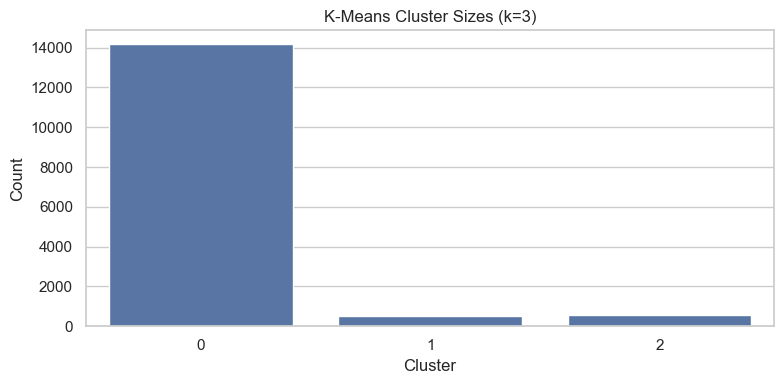

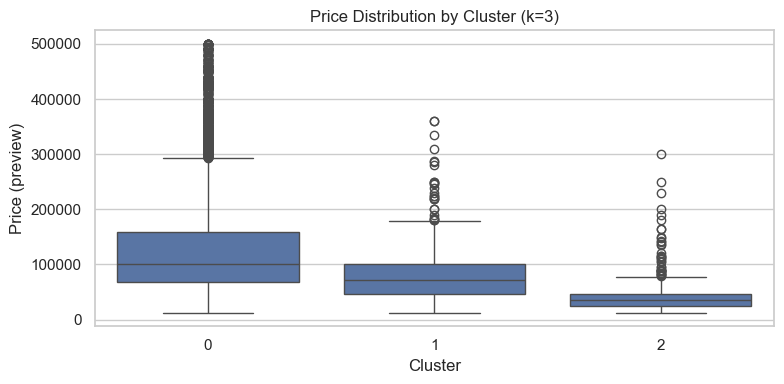

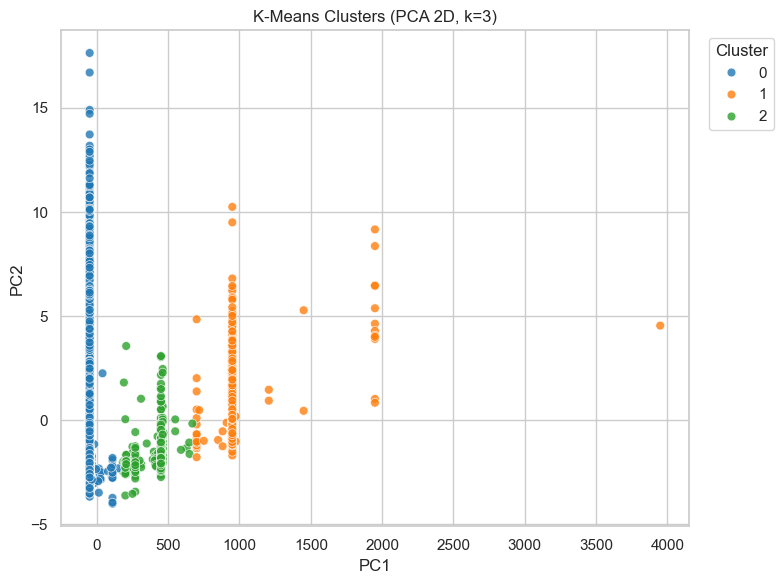

K-Means (k=4) cluster sizes:


,count
cluster,
0,14161
1,485
2,13
3,550


price_preview                                   cpu_mark           \
                  mean    median      min       max          mean   median   
cluster                                                                      
0        124410.526586  100000.0  12340.0  500000.0  12260.353647  10769.0   
1         81514.779381   70000.0  12340.0  360000.0   5615.111340   5085.0   
2        126923.076923  109000.0  40000.0  310000.0   9500.307692   7491.0   
3         42277.247273   35000.0  12345.0  300000.0   2840.274545   2177.0   

                     gpu_g3d_mark          ... HDD_SIZE            gpu_tdp  \
          min    max         mean  median  ...      min     max       mean   
cluster                                    ...                               
0         123  57591  4855.441565  1200.0  ...      0.0   200.0  52.187557   
1         156  42244  3053.740206  1042.0  ...    750.0  1500.0  50.282474   
2        1320  26927  6192.153846  5044.0  ...   2000.0  4000.0  81.153846   
3         344  22850   645.732727   400.0  ...    232.0   720.0  28.378182   

                            match_score                           
        median   min    max        mean median        min    max  
cluster                                                           
0         15.0   6.0  575.0   91.457241  100.0  60.000000  100.0  
1         25.0  10.0  320.0   88.138610  100.0  60.000000  100.0  
2         75.0  20.0  175.0   95.338629  100.0  68.750000  100.0  
3         25.0   6.0  230.0   94.275339  100.0  61.538462  100.0  

[4 rows x 32 columns]

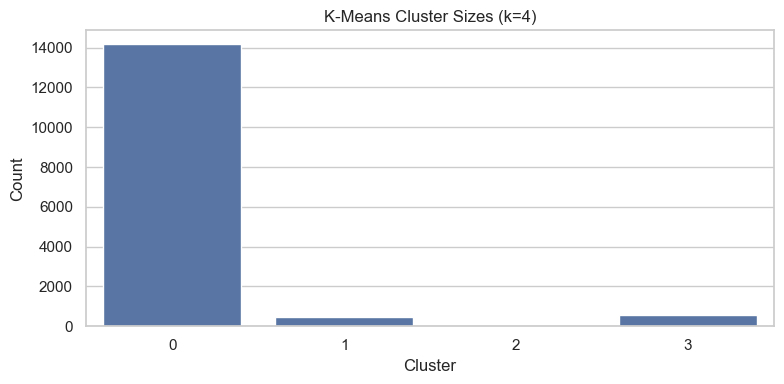

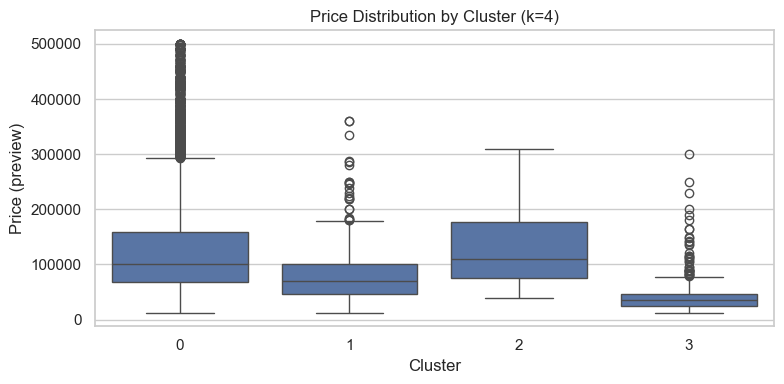

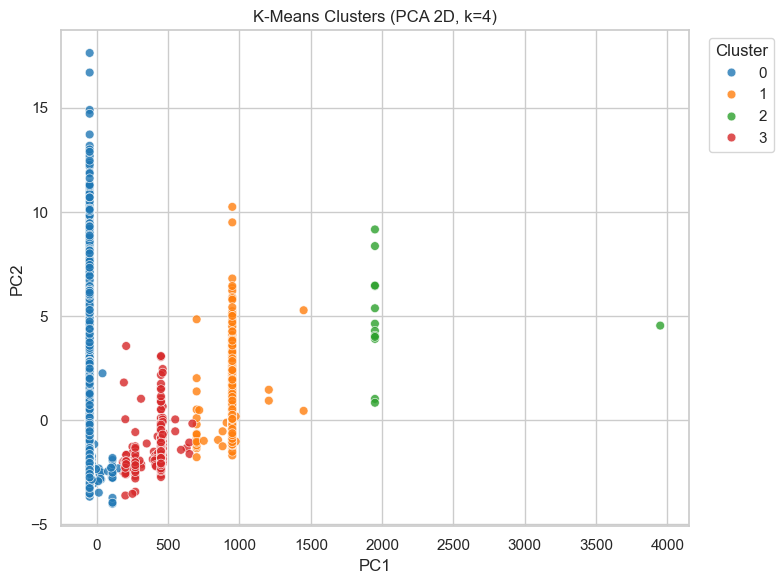

In [6]:
# Summarize and visualize K-Means with k=3 and k=4
feature_variance = X_clust_source.var().sort_values(ascending=False)
top_features = feature_variance.head(8).index.tolist()
summary_cols = ["price_preview"] + [c for c in top_features if c != "price_preview"]

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_all_scaled)

for k in [3, 4]:
    kmeans_k = KMeans(n_clusters=k, init="k-means++", n_init=20, max_iter=500, random_state=42)
    labels_k = kmeans_k.fit_predict(X_all_scaled)

    cluster_df_k = X_clust_source.copy()
    cluster_df_k["cluster"] = labels_k

    cluster_sizes_k = cluster_df_k["cluster"].value_counts().sort_index()
    print(f"K-Means (k={k}) cluster sizes:")
    display(cluster_sizes_k.to_frame(name="count"))

    cluster_summary_k = cluster_df_k.groupby("cluster")[summary_cols].agg(["mean", "median", "min", "max"])
    display(cluster_summary_k)

    plt.figure(figsize=(8, 4))
    sns.barplot(x=cluster_sizes_k.index, y=cluster_sizes_k.values, color="#4C72B0")
    plt.title(f"K-Means Cluster Sizes (k={k})")
    plt.xlabel("Cluster")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.boxplot(data=cluster_df_k, x="cluster", y="price_preview")
    plt.title(f"Price Distribution by Cluster (k={k})")
    plt.xlabel("Cluster")
    plt.ylabel("Price (preview)")
    plt.tight_layout()
    plt.show()

    pca_df_k = pd.DataFrame(pca_coords, columns=["PC1", "PC2"])
    pca_df_k["cluster"] = labels_k

    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=pca_df_k, x="PC1", y="PC2", hue="cluster", palette="tab10", s=40, alpha=0.8)
    plt.title(f"K-Means Clusters (PCA 2D, k={k})")
    plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## Model Summary & Presentation Charts

The following section consolidates the main model results and provides presentation-ready visuals (performance comparison, residuals, and learning curves).

In [5]:
sns.set(style="whitegrid")



# -------------------------
# 1) Summary Table
# -------------------------
summary_rows = []

if "baseline" in globals():
    summary_rows.append({
        "Model": "Baseline",
        "R2": np.nan,
        "RMSE": baseline
    })

if "be_r2" in globals() and "be_rmse" in globals():
    summary_rows.append({
        "Model": "Backward Elimination",
        "R2": be_r2,
        "RMSE": be_rmse
    })

if "tuned_r2" in globals() and "tuned_rmse" in globals():
    summary_rows.append({
        "Model": "Tuned XGBoost",
        "R2": tuned_r2,
        "RMSE": tuned_rmse
    })

if "aug_r2" in globals() and "aug_rmse" in globals():
    summary_rows.append({
        "Model": "Augmented XGBoost",
        "R2": aug_r2,
        "RMSE": aug_rmse
    })

summary_df = pd.DataFrame(summary_rows)
# This block was copied over from the regression notebook; none of the
# variables it looks for exist here, so summary_rows is empty and the sort
# raised KeyError("RMSE"). Guard it rather than sort an empty frame.
if not summary_df.empty:
    summary_df = summary_df.sort_values("RMSE", ascending=True, na_position="last")

print("\n=== Model Performance Summary ===")
print(summary_df.to_string(index=False))

# -------------------------
# 2) Performance Bars
# -------------------------
if not summary_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # RMSE bar chart
    if sns:
        sns.barplot(data=summary_df, x="Model", y="RMSE", ax=axes[0], palette="viridis")
    else:
        axes[0].bar(summary_df["Model"], summary_df["RMSE"], color="#4C72B0")
    axes[0].set_title("RMSE (Lower is Better)")
    axes[0].tick_params(axis='x', rotation=25)

    # R2 bar chart
    r2_df = summary_df.dropna(subset=["R2"])
    if not r2_df.empty:
        if sns:
            sns.barplot(data=r2_df, x="Model", y="R2", ax=axes[1], palette="mako")
        else:
            axes[1].bar(r2_df["Model"], r2_df["R2"], color="#55A868")
        axes[1].set_title("R² (Higher is Better)")
        axes[1].tick_params(axis='x', rotation=25)
    else:
        axes[1].axis("off")
        axes[1].set_title("R² not available")

    plt.tight_layout()
    plt.show()

# -------------------------
# 3) Residuals & Actual vs Predicted (best available)
# -------------------------
# Pick best available prediction set
pred = None
actual = None
label = ""

if "y_pred_aug" in globals() and "y_test_original" in globals():
    pred = y_pred_aug
    actual = y_test_original
    label = "Augmented XGBoost"
elif "y_pred_tuned" in globals() and "y_test_original" in globals():
    pred = y_pred_tuned
    actual = y_test_original
    label = "Tuned XGBoost"
elif "y_pred_be" in globals() and "y_test_original" in globals():
    pred = y_pred_be
    actual = y_test_original
    label = "Backward Elimination"

if pred is not None and actual is not None:
    residuals = actual - pred

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Actual vs Predicted
    axes[0].scatter(actual, pred, alpha=0.6)
    axes[0].plot([actual.min(), actual.max()], [actual.min(), actual.max()], "r--")
    axes[0].set_title(f"Actual vs Predicted ({label})")
    axes[0].set_xlabel("Actual Price")
    axes[0].set_ylabel("Predicted Price")

    # Residuals
    if sns:
        sns.histplot(residuals, kde=True, ax=axes[1], color="#4C72B0")
    else:
        axes[1].hist(residuals, bins=30, color="#4C72B0", alpha=0.7)
    axes[1].axvline(0, color="r", linestyle="--")
    axes[1].set_title("Residuals Distribution")
    axes[1].set_xlabel("Residual (Actual - Predicted)")

    plt.tight_layout()
    plt.show()

# -------------------------
# 4) Learning Curve (Overfitting Check)
# -------------------------
# Choose best available training data
X_lc = None
y_lc = None
estimator = None

if "best_tuned_model" in globals() and "X_train_scaled_aug" in globals() and "y_train_aug" in globals():
    estimator = best_tuned_model
    X_lc = X_train_scaled_aug
    y_lc = y_train_aug
elif "best_tuned_model" in globals() and "X_train_scaled" in globals() and "y_train" in globals():
    estimator = best_tuned_model
    X_lc = X_train_scaled
    y_lc = y_train
elif "final_pipeline" in globals() and "X_train" in globals() and "y_train" in globals():
    estimator = final_pipeline
    X_lc = X_train
    y_lc = y_train

if estimator is not None and X_lc is not None and y_lc is not None:
    train_sizes, train_scores, val_scores = learning_curve(
        clone(estimator),
        X_lc,
        y_lc,
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        scoring="neg_root_mean_squared_error",
        train_sizes=np.linspace(0.2, 1.0, 5),
        n_jobs=-1
    )

    train_rmse = -np.mean(train_scores, axis=1)
    val_rmse = -np.mean(val_scores, axis=1)

    plt.figure(figsize=(7, 4))
    plt.plot(train_sizes, train_rmse, "o-", label="Train RMSE")
    plt.plot(train_sizes, val_rmse, "o-", label="Validation RMSE")
    plt.title("Learning Curve (RMSE)")
    plt.xlabel("Training Set Size")
    plt.ylabel("RMSE")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Simple overfitting indicator
    gap = val_rmse[-1] - train_rmse[-1]
    print(f"Final RMSE gap (val - train): {gap:.3f}")
else:
    print("Learning curve skipped (required model/data not found).")


KeyError: 'RMSE'